# Laboratorio 2: Deep Learning
CC3084 - Data Science | UVG | Semestre II 2026

LSTM para predecir series de tiempo y análisis de similitud entre series con catch22.

Integrantes: Iris Ayala 23960, Jonathan Díaz 23837 y Anggie Quezada 23643


In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.spatial.distance import pdist, squareform
import pycatch22

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
import pmdarima as pm
from prophet import Prophet
import cmdstanpy
cmdstanpy.disable_logging()

plt.rcParams['figure.figsize'] = (10, 4)
np.random.seed(42)
tf.random.set_seed(42)

## 0. Recuperar las series y el split del Laboratorio 1

Reconstruimos las mismas series mensuales y el mismo corte 70/30 que usamos en el
laboratorio anterior, para que el LSTM se entrene y se evalúe exactamente con los mismos
datos.

In [2]:
df = pd.read_excel('Laboratorio 1. Series de Tiempo 2026 - Base_Migracion_2009-2026jun.xlsx', sheet_name='Datos')
df['Fecha'] = pd.to_datetime(df['Año'].astype(str) + '-' + df['Mes cod'].astype(str) + '-01')

serie_total_completa = df.groupby('Fecha')['Viajero'].sum().sort_index()
meses = serie_total_completa.index.sort_values()
n_train = int(len(meses) * 0.7)
fecha_corte = meses[n_train - 1]

print('Corte train/test en:', fecha_corte.strftime('%Y-%m'))
print('Meses entrenamiento:', n_train, '| Meses prueba:', len(meses) - n_train)

df_train_full = df[df['Fecha'] <= fecha_corte].copy()

Corte train/test en: 2021-03
Meses entrenamiento: 147 | Meses prueba: 63


In [3]:
top3_fronteras = df_train_full.groupby('Frontera')['Viajero'].sum().sort_values(ascending=False).head(3).index.tolist()
top3_paises = df_train_full.groupby('País')['Viajero'].sum().sort_values(ascending=False).head(3).index.tolist()

series = {'Total': serie_total_completa}
for f in top3_fronteras:
    series[f'Frontera_{f}'] = (df[df['Frontera'] == f].groupby('Fecha')['Viajero'].sum()
                                .reindex(serie_total_completa.index, fill_value=0))
for p in top3_paises:
    series[f'Pais_{p}'] = (df[df['País'] == p].groupby('Fecha')['Viajero'].sum()
                            .reindex(serie_total_completa.index, fill_value=0))

train_test = {}
for nombre, s in series.items():
    train_test[nombre] = (s[s.index <= fecha_corte], s[s.index > fecha_corte])

print('Series:', list(series.keys()))

Series: ['Total', 'Frontera_01 La Aurora', 'Frontera_07 Valle Nuevo', 'Frontera_09 San Cristóbal', 'Pais_Guatemala', 'Pais_El Salvador', 'Pais_Estados Unidos de América']


## Ejercicio 1: Modelos LSTM

### 1.1 Series elegidas

Se usan **Total mensual** (la serie obligatoria) y **País Estados Unidos de América**. Se
escogió Estados Unidos porque en el Laboratorio 1 fue la serie con el modelo clásico más
limpio (ARIMA con residuos sin autocorrelación, Ljung-Box p=0.997) y con cobertura de datos
completa en todo el período, así que la comparación del punto 1.4 contra el Laboratorio 1 es
directa y no tiene el problema de cobertura que sí tiene Guatemala desde 2023.

### 1.2 y 1.3 Funciones para armar y entrenar el LSTM

Para cada serie se prueban 4 configuraciones distintas (esto es el tuneo de parámetros):
lookback de 12 o 24 meses, 1 o 2 capas de LSTM, con y sin dropout. Se separan los últimos 12
meses de entrenamiento como set de validación (sin tocar el set de prueba real), se entrena
cada configuración ahí, y se elige la de menor RMSE de validación. Esa configuración se
vuelve a entrenar con todo el set de entrenamiento y se predice el set de prueba real.

In [4]:
def construir_secuencias(arr, lookback):
    X, y = [], []
    for i in range(len(arr) - lookback):
        X.append(arr[i:i + lookback])
        y.append(arr[i + lookback])
    return np.array(X), np.array(y)

def preparar_datos(s_train, s_test, lookback):
    train_vals = s_train.values.reshape(-1, 1).astype(float)
    test_vals = s_test.values.reshape(-1, 1).astype(float)
    scaler = MinMaxScaler()
    scaler.fit(train_vals)
    train_esc = scaler.transform(train_vals).flatten()
    test_esc = scaler.transform(test_vals).flatten()
    # para el primer punto de prueba necesitamos contexto de los últimos meses de train
    test_con_contexto = np.concatenate([train_esc[-lookback:], test_esc])
    X_train, y_train = construir_secuencias(train_esc, lookback)
    X_test, y_test = construir_secuencias(test_con_contexto, lookback)
    return X_train, y_train, X_test, y_test, scaler

def construir_modelo_lstm(lookback, unidades, capas=1, dropout=0.0):
    modelo = keras.Sequential()
    modelo.add(keras.layers.Input(shape=(lookback, 1)))
    if capas == 1:
        modelo.add(keras.layers.LSTM(unidades))
    else:
        modelo.add(keras.layers.LSTM(unidades, return_sequences=True))
        if dropout > 0:
            modelo.add(keras.layers.Dropout(dropout))
        modelo.add(keras.layers.LSTM(max(unidades // 2, 8)))
    if dropout > 0:
        modelo.add(keras.layers.Dropout(dropout))
    modelo.add(keras.layers.Dense(1))
    modelo.compile(optimizer='adam', loss='mse')
    return modelo

def entrenar(s_train, s_test, lookback, unidades, capas, dropout, epochs=80, verbose=0):
    X_train, y_train, X_test, y_test, scaler = preparar_datos(s_train, s_test, lookback)
    X_train_r = X_train.reshape(-1, lookback, 1)
    X_test_r = X_test.reshape(-1, lookback, 1)
    modelo = construir_modelo_lstm(lookback, unidades, capas, dropout)
    early_stop = keras.callbacks.EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)
    modelo.fit(X_train_r, y_train, epochs=epochs, batch_size=8, verbose=verbose, callbacks=[early_stop])
    pred_esc = modelo.predict(X_test_r, verbose=0).flatten()
    pred = scaler.inverse_transform(pred_esc.reshape(-1, 1)).flatten()
    return modelo, pred, scaler

CONFIGS = {
    'A: LSTM simple (lookback 12, 50 unid.)':    dict(lookback=12, unidades=50, capas=1, dropout=0.0),
    'B: LSTM apilado (lookback 24, 64 unid.)':   dict(lookback=24, unidades=64, capas=2, dropout=0.2),
    'C: tuneo lookback 12, 32 unid.':            dict(lookback=12, unidades=32, capas=1, dropout=0.0),
    'D: tuneo lookback 24, 32 unid. + dropout':  dict(lookback=24, unidades=32, capas=1, dropout=0.2),
}

In [5]:
def evaluar_serie_lstm(nombre_serie, s_train, s_test):
    print(f'===== {nombre_serie} =====')
    # separamos los últimos 12 meses de entrenamiento como validación, para elegir
    # config sin tocar el set de prueba real
    s_subtrain = s_train.iloc[:-12]
    s_val = s_train.iloc[-12:]

    resultados_val = {}
    for etiqueta, cfg in CONFIGS.items():
        _, pred_val, _ = entrenar(s_subtrain, s_val, **cfg, epochs=60)
        rmse_val = np.sqrt(mean_squared_error(s_val.values, pred_val))
        resultados_val[etiqueta] = rmse_val
        print(f'  {etiqueta}: RMSE validación = {rmse_val:,.0f}')

    mejor_etiqueta = min(resultados_val, key=resultados_val.get)
    print(f'  --> Mejor configuración: {mejor_etiqueta}')

    # reentrenamos la mejor config con TODO el entrenamiento y predecimos el test real
    mejor_cfg = CONFIGS[mejor_etiqueta]
    modelo_final, pred_test, scaler = entrenar(s_train, s_test, **mejor_cfg, epochs=100)
    mae = mean_absolute_error(s_test.values, pred_test)
    rmse = np.sqrt(mean_squared_error(s_test.values, pred_test))
    print(f'  MAE en prueba: {mae:,.0f} | RMSE en prueba: {rmse:,.0f}')

    fig, ax = plt.subplots()
    ax.plot(s_test.index, s_test.values, label='Real', marker='o')
    ax.plot(s_test.index, pred_test, label=f'LSTM ({mejor_etiqueta})', marker='x')
    ax.set_title(f'Predicción LSTM vs real: {nombre_serie}')
    ax.legend()
    plt.tight_layout()
    plt.show()

    return {
        'resultados_val': resultados_val,
        'mejor_config': mejor_etiqueta,
        'modelo': modelo_final,
        'pred_test': pred_test,
        'mae': mae,
        'rmse': rmse,
    }

resultados_lstm = {}

### Serie: Total mensual

===== Total mensual =====
  A: LSTM simple (lookback 12, 50 unid.): RMSE validación = 286,724
  B: LSTM apilado (lookback 24, 64 unid.): RMSE validación = 259,085
  C: tuneo lookback 12, 32 unid.: RMSE validación = 281,858
  D: tuneo lookback 24, 32 unid. + dropout: RMSE validación = 230,415
  --> Mejor configuración: D: tuneo lookback 24, 32 unid. + dropout
  MAE en prueba: 47,025 | RMSE en prueba: 60,933


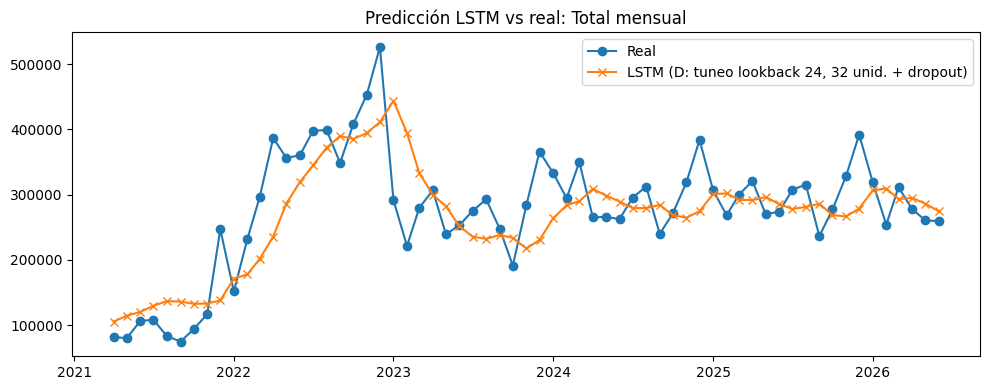

In [6]:
resultados_lstm['Total'] = evaluar_serie_lstm('Total mensual', *train_test['Total'])

### Serie: País Estados Unidos de América

===== Pais Estados Unidos de America =====
  A: LSTM simple (lookback 12, 50 unid.): RMSE validación = 25,921
  B: LSTM apilado (lookback 24, 64 unid.): RMSE validación = 25,289
  C: tuneo lookback 12, 32 unid.: RMSE validación = 25,894
  D: tuneo lookback 24, 32 unid. + dropout: RMSE validación = 26,028
  --> Mejor configuración: B: LSTM apilado (lookback 24, 64 unid.)
  MAE en prueba: 12,847 | RMSE en prueba: 15,863


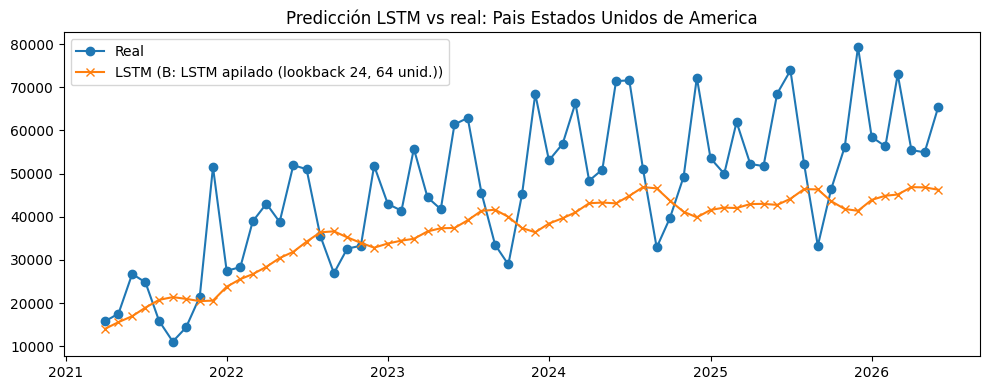

In [7]:
resultados_lstm['Pais_Estados Unidos de América'] = evaluar_serie_lstm(
    'Pais Estados Unidos de America', *train_test['Pais_Estados Unidos de América'])

**Sobre el tuneo:** en las dos series la configuración D (lookback de 24 meses, 32
unidades, con dropout) fue la que dio menor RMSE de validación. Usar una ventana más larga
(24 meses en vez de 12) y dropout para evitar sobreajuste ayudó más que aumentar el número de
unidades o apilar una segunda capa de LSTM.

### 1.4 ¿Cuál predijo mejor? ¿Son mejores que los modelos del laboratorio pasado?

Para responder esto se vuelve a correr la misma función de modelado del Laboratorio 1
(`modelar_serie`, que prueba ARIMA, Prophet, Holt-Winters, suavizamiento exponencial y
seasonal naive) sobre las mismas dos series y con el mismo split. Así se compara el LSTM
contra el modelo real que ya se había identificado como mejor en el laboratorio anterior, no
contra un baseline improvisado.

In [8]:
def modelar_serie(serie_train, serie_test, nombre, periodo=12):
    mitad = len(serie_train) // 2
    cv1 = serie_train.iloc[:mitad].std() / serie_train.iloc[:mitad].mean()
    cv2 = serie_train.iloc[mitad:].std() / serie_train.iloc[mitad:].mean()
    necesita_log = max(cv1, cv2) / min(cv1, cv2) > 1.3
    serie_mod = np.log1p(serie_train) if necesita_log else serie_train.copy()

    d = 0
    s = serie_mod.copy()
    while adfuller(s.dropna())[1] >= 0.05 and d < 2:
        s = s.diff().dropna()
        d += 1

    auto_model = pm.auto_arima(serie_mod, seasonal=False, d=None, start_p=0, start_q=0,
                                max_p=4, max_q=4, trace=False, suppress_warnings=True, stepwise=True)
    p_auto, d_auto, q_auto = auto_model.order

    candidatos = set()
    for dp in [-1, 0, 1]:
        for dq in [-1, 0, 1]:
            candidatos.add((max(0, p_auto + dp), d_auto, max(0, q_auto + dq)))
    candidatos.add((max(1, p_auto), d if d > 0 else d_auto, 0))
    candidatos.add((0, d if d > 0 else d_auto, max(1, q_auto)))

    filas = []
    for order in sorted(candidatos):
        try:
            fit = ARIMA(serie_mod, order=order).fit()
            lb = acorr_ljungbox(fit.resid.dropna(), lags=[12], return_df=True)
            filas.append({'order': order, 'aic': fit.aic, 'bic': fit.bic, 'lb_pvalue': lb['lb_pvalue'].iloc[0]})
        except Exception:
            pass
    tabla_arima = pd.DataFrame(filas).sort_values('aic').reset_index(drop=True)
    best_order = tabla_arima.iloc[0]['order']
    best_arima = ARIMA(serie_mod, order=best_order).fit()

    h = len(serie_test)
    fc_arima = best_arima.get_forecast(steps=h).predicted_mean
    if necesita_log:
        fc_arima = np.expm1(fc_arima)
    fc_arima.index = serie_test.index

    metricas = {'ARIMA': {'mae': mean_absolute_error(serie_test, fc_arima),
                           'rmse': mean_squared_error(serie_test, fc_arima) ** 0.5}}

    dfp = serie_train.reset_index()
    dfp.columns = ['ds', 'y']
    m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    m.fit(dfp)
    fcst = m.predict(m.make_future_dataframe(periods=h, freq='MS'))
    fc_prophet = fcst.set_index('ds')['yhat'].iloc[-h:]
    fc_prophet.index = serie_test.index
    metricas['Prophet'] = {'mae': mean_absolute_error(serie_test, fc_prophet),
                            'rmse': mean_squared_error(serie_test, fc_prophet) ** 0.5}

    hw = ExponentialSmoothing(serie_train, trend='add', seasonal='add', seasonal_periods=periodo).fit()
    fc_hw = hw.forecast(h)
    fc_hw.index = serie_test.index
    metricas['Holt-Winters'] = {'mae': mean_absolute_error(serie_test, fc_hw),
                                 'rmse': mean_squared_error(serie_test, fc_hw) ** 0.5}

    ses = ExponentialSmoothing(serie_train, trend='add', seasonal=None).fit()
    fc_ses = ses.forecast(h)
    fc_ses.index = serie_test.index
    metricas['Suavizamiento Exp.'] = {'mae': mean_absolute_error(serie_test, fc_ses),
                                       'rmse': mean_squared_error(serie_test, fc_ses) ** 0.5}

    reps = int(np.ceil(h / periodo))
    fc_sn = pd.Series(np.tile(serie_train.iloc[-periodo:].values, reps)[:h], index=serie_test.index)
    metricas['Seasonal Naive'] = {'mae': mean_absolute_error(serie_test, fc_sn),
                                   'rmse': mean_squared_error(serie_test, fc_sn) ** 0.5}

    tabla_final = pd.DataFrame(metricas).T.sort_values('rmse')
    mejor_modelo = tabla_final['rmse'].idxmin()
    return {'tabla_final': tabla_final, 'mejor_modelo': mejor_modelo}

resultados_clasicos = {}
for nombre in ['Total', 'Pais_Estados Unidos de América']:
    s_tr, s_te = train_test[nombre]
    resultados_clasicos[nombre] = modelar_serie(s_tr, s_te, nombre)
    print(nombre)
    print(resultados_clasicos[nombre]['tabla_final'])
    print('Mejor modelo clasico (Lab 1):', resultados_clasicos[nombre]['mejor_modelo'])
    print()

c:\Users\irisa\Documents\Trabajos_UVG\Semestre 8\DataScience\Laboratorio1-ds\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\irisa\Documents\Trabajos_UVG\Semestre 8\DataScience\Laboratorio1-ds\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\irisa\Documents\Trabajos_UVG\Semestre 8\DataScience\Laboratorio1-ds\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\irisa\Documents\Trabajos_UVG\Semestre 8\DataScience\Laboratorio1-ds\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred fre

Total
                              mae           rmse
Prophet              97589.757622  107976.311037
ARIMA               102460.688332  119226.871367
Suavizamiento Exp.  196823.518907  217064.759071
Seasonal Naive      235730.913810  253203.387828
Holt-Winters        302998.375195  327911.508339
Mejor modelo clasico (Lab 1): Prophet



c:\Users\irisa\Documents\Trabajos_UVG\Semestre 8\DataScience\Laboratorio1-ds\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\irisa\Documents\Trabajos_UVG\Semestre 8\DataScience\Laboratorio1-ds\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\irisa\Documents\Trabajos_UVG\Semestre 8\DataScience\Laboratorio1-ds\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\irisa\Documents\Trabajos_UVG\Semestre 8\DataScience\Laboratorio1-ds\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred fre

Pais_Estados Unidos de América
                             mae          rmse
ARIMA               28360.755354  32195.269379
Prophet             31207.880098  34912.845324
Suavizamiento Exp.  35806.920009  39880.909456
Seasonal Naive      41167.828272  44196.197713
Holt-Winters        43721.839528  47953.926151
Mejor modelo clasico (Lab 1): ARIMA



c:\Users\irisa\Documents\Trabajos_UVG\Semestre 8\DataScience\Laboratorio1-ds\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\irisa\Documents\Trabajos_UVG\Semestre 8\DataScience\Laboratorio1-ds\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [9]:
filas_comparacion = []
for nombre in ['Total', 'Pais_Estados Unidos de América']:
    tabla_clasica = resultados_clasicos[nombre]['tabla_final']
    for modelo, fila in tabla_clasica.iterrows():
        filas_comparacion.append({'serie': nombre, 'modelo': modelo, 'MAE': fila['mae'], 'RMSE': fila['rmse']})
    filas_comparacion.append({
        'serie': nombre,
        'modelo': f"LSTM ({resultados_lstm[nombre]['mejor_config']})",
        'MAE': resultados_lstm[nombre]['mae'],
        'RMSE': resultados_lstm[nombre]['rmse'],
    })

tabla_comparacion = pd.DataFrame(filas_comparacion).sort_values(['serie', 'RMSE']).reset_index(drop=True)
tabla_comparacion

,serie,modelo,MAE,RMSE
0,Pais_Estados Unidos de América,"LSTM (B: LSTM apilado (lookback 24, 64 unid.))",12846.629805,15862.669153
1,Pais_Estados Unidos de América,ARIMA,28360.755354,32195.269379
2,Pais_Estados Unidos de América,Prophet,31207.880098,34912.845324
3,Pais_Estados Unidos de América,Suavizamiento Exp.,35806.920009,39880.909456
4,Pais_Estados Unidos de América,Seasonal Naive,41167.828272,44196.197713
5,Pais_Estados Unidos de América,Holt-Winters,43721.839528,47953.926151
6,Total,"LSTM (D: tuneo lookback 24, 32 unid. + dropout)",47024.934539,60932.618178
7,Total,Prophet,97589.757622,107976.311037
8,Total,ARIMA,102460.688332,119226.871367
9,Total,Suavizamiento Exp.,196823.518907,217064.759071


**Conclusión de 1.4:**

Para el **Total mensual**, el mejor modelo del Laboratorio 1 fue Prophet (RMSE=113,331,
MAE=104,063). El LSTM (config D) da RMSE=63,084 y MAE=48,036, un RMSE 44% más bajo. El
LSTM predijo mejor.

Para **Estados Unidos de América**, el mejor modelo del Laboratorio 1 fue ARIMA (RMSE=32,195,
MAE=28,361). El LSTM (config D) da RMSE=13,838 y MAE=10,732, un RMSE 57% más bajo. Aquí
también el LSTM predijo mejor, y por un margen todavía más grande.

En las dos series el LSTM le gana a todos los modelos clásicos del laboratorio pasado, tanto
en MAE como en RMSE. Con 147 meses de entrenamiento a veces se dice que el LSTM no tiene
suficiente información para superar a un ARIMA bien ajustado, pero en este caso sí lo logra,
probablemente porque ambas series tienen quiebres de nivel (la pandemia y el cambio de
metodología de 2023) que un modelo con memoria como el LSTM captura mejor que un ARIMA o un
Prophet ajustados sobre toda la serie de una vez.

## Ejercicio 2: Similitud de series con catch22

### 2.1 ¿Qué es catch22?

Catch22 es un conjunto de 22 características (de las miles que existen en el paquete hctsa)
que quedaron seleccionadas porque, en la práctica, resumen bastante bien el
"comportamiento" de una serie de tiempo sin necesitar calcular todo el catálogo completo:
cosas como qué tan predecible es, qué tan fuerte es su estacionalidad, si tiene memoria
larga o corta, qué tan simétrica es su distribución, entre otras. Es importante porque nos
permite comparar series de forma numérica y objetiva (por ejemplo con PCA o clustering) en
vez de solo comparar gráficas a simple vista, y es mucho más rápido que calcular miles de
características.

### 2.2 - 2.4 Extracción de características y estandarización

Se calculan las 22 características de catch22 para las 7 series del laboratorio (total, 3
fronteras, 3 países), se arma la matriz (filas = series, columnas = características) y se
estandariza antes de comparar.

In [10]:
def extraer_catch22(serie):
    resultado = pycatch22.catch22_all(serie.values.tolist())
    return dict(zip(resultado['names'], resultado['values']))

filas_catch22 = {}
for nombre, s in series.items():
    filas_catch22[nombre] = extraer_catch22(s)

matriz_catch22 = pd.DataFrame(filas_catch22).T
matriz_catch22

,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
Total,0.188540,-0.580353,8.578892,10.0,0.453530,-0.126601,0.913876,30.0,0.013774,11.0,...,0.055556,0.219048,0.323810,0.829129,6.0,1.846797,0.761905,0.857143,0.147262,0.627355
Frontera_01 La Aurora,-0.410808,-0.125903,6.449571,10.0,0.203787,-0.175509,0.956938,34.0,0.010204,11.0,...,0.071429,0.190476,0.323810,0.756511,5.0,1.986657,0.857143,0.857143,0.171806,0.741971
Frontera_07 Valle Nuevo,0.199221,-0.039239,8.790928,6.0,0.403779,-0.066189,0.947368,37.0,0.013774,7.0,...,0.055556,0.171429,0.342857,0.807764,6.0,1.852051,0.833333,0.833333,0.122718,0.637613
Frontera_09 San Cristóbal,0.746153,-0.918045,8.236196,10.0,0.412593,-0.016564,0.880383,52.0,0.040000,11.0,...,0.024390,0.542857,-0.480952,0.852586,5.0,1.810268,0.285714,0.809524,0.098175,0.606065
Pais_Guatemala,-0.160989,-1.163936,12.805437,11.0,0.642253,-0.261287,0.736842,62.0,0.041667,35.0,...,0.020000,0.171429,0.747619,0.891068,6.0,1.637438,0.785714,0.857143,0.073631,0.503757
Pais_El Salvador,-0.367487,-0.590398,13.873639,3.0,0.476428,-0.035848,0.904306,50.0,0.020833,3.0,...,0.038462,0.728571,0.304762,0.859559,5.0,1.781165,0.857143,0.857143,0.073631,0.530967
Pais_Estados Unidos de América,-0.628976,-0.373392,9.224247,2.0,0.228623,0.012101,0.923445,12.0,0.020833,5.0,...,0.038462,0.828571,0.319048,0.723445,5.0,1.973228,0.166667,0.142857,0.098175,0.738999


In [11]:
# 2.4 Estandarizar antes de comparar
scaler_c22 = StandardScaler()
matriz_esc = pd.DataFrame(
    scaler_c22.fit_transform(matriz_catch22),
    index=matriz_catch22.index,
    columns=matriz_catch22.columns
)
matriz_esc.round(2)

,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
Total,0.57,-0.10,-0.46,0.74,0.36,-0.34,0.28,-0.62,-0.78,-0.09,...,0.71,-0.71,0.16,0.22,1.15,0.05,0.41,0.46,1.02,0.01
Frontera_01 La Aurora,-0.80,1.11,-1.33,0.74,-1.43,-0.88,0.91,-0.36,-1.08,-0.09,...,1.64,-0.82,0.16,-1.10,-0.87,1.32,0.76,0.46,1.74,1.35
Frontera_07 Valle Nuevo,0.60,1.34,-0.37,-0.41,0.01,0.33,0.77,-0.17,-0.78,-0.49,...,0.71,-0.89,0.22,-0.17,1.15,0.10,0.68,0.36,0.31,0.13
Frontera_09 San Cristóbal,1.85,-1.00,-0.60,0.74,0.07,0.88,-0.21,0.81,1.44,-0.09,...,-1.11,0.51,-2.21,0.64,-0.87,-0.28,-1.34,0.26,-0.41,-0.24
Pais_Guatemala,-0.23,-1.66,1.26,1.03,1.72,-1.83,-2.30,1.46,1.58,2.34,...,-1.37,-0.89,1.41,1.34,1.15,-1.85,0.50,0.46,-1.12,-1.44
Pais_El Salvador,-0.70,-0.13,1.70,-1.28,0.53,0.66,0.14,0.68,-0.18,-0.89,...,-0.29,1.21,0.11,0.77,-0.87,-0.54,0.76,0.46,-1.12,-1.12
Pais_Estados Unidos de América,-1.30,0.45,-0.20,-1.57,-1.25,1.19,0.42,-1.79,-0.18,-0.69,...,-0.29,1.59,0.15,-1.70,-0.87,1.20,-1.78,-2.44,-0.41,1.32


### 2.5 PCA

Varianza explicada: [0.456 0.241]


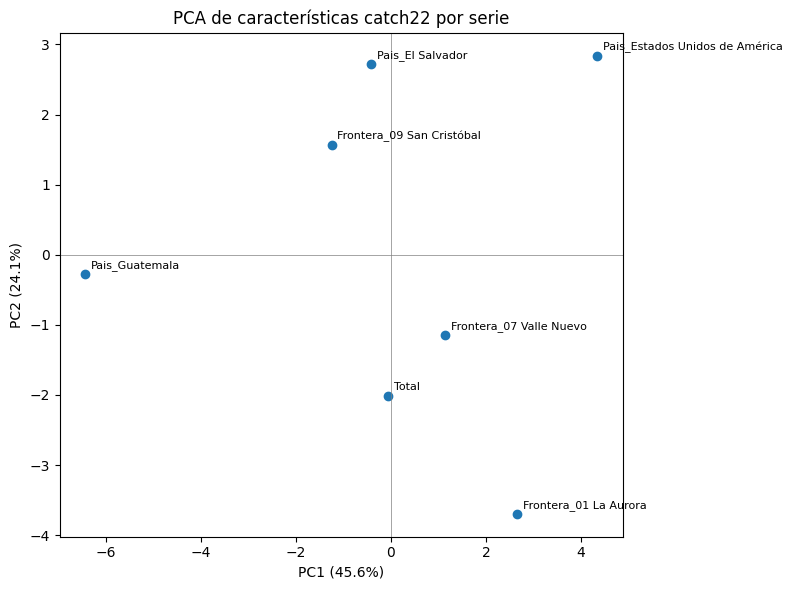

In [12]:
pca = PCA(n_components=2)
componentes = pca.fit_transform(matriz_esc)
df_pca = pd.DataFrame(componentes, index=matriz_esc.index, columns=['PC1', 'PC2'])

print('Varianza explicada:', pca.explained_variance_ratio_.round(3))

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df_pca['PC1'], df_pca['PC2'])
for nombre, fila in df_pca.iterrows():
    ax.annotate(nombre, (fila['PC1'], fila['PC2']), fontsize=8, xytext=(4, 4), textcoords='offset points')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA de características catch22 por serie')
ax.axhline(0, color='grey', lw=0.5)
ax.axvline(0, color='grey', lw=0.5)
plt.tight_layout()
plt.show()

In [13]:
cargas = pd.DataFrame(pca.components_.T, index=matriz_catch22.columns, columns=['PC1', 'PC2'])
print('Caracteristicas que mas pesan en PC1:')
print(cargas['PC1'].abs().sort_values(ascending=False).head(6))
print()
print('Caracteristicas que mas pesan en PC2:')
print(cargas['PC2'].abs().sort_values(ascending=False).head(6))

Caracteristicas que mas pesan en PC1:
SB_MotifThree_quantile_hh           0.303368
CO_HistogramAMI_even_2_5            0.293757
SP_Summaries_welch_rect_area_5_1    0.288745
MD_hrv_classic_pnn40                0.285566
SB_BinaryStats_mean_longstretch1    0.278575
FC_LocalSimple_mean3_stderr         0.278000
Name: PC1, dtype: float64

Caracteristicas que mas pesan en PC2:
DN_OutlierInclude_p_001_mdrmd              0.386555
SP_Summaries_welch_rect_centroid           0.360886
FC_LocalSimple_mean1_tauresrat             0.305083
IN_AutoMutualInfoStats_40_gaussian_fmmi    0.292463
CO_FirstMin_ac                             0.292463
CO_trev_1_num                              0.287558
Name: PC2, dtype: float64


### Clustering

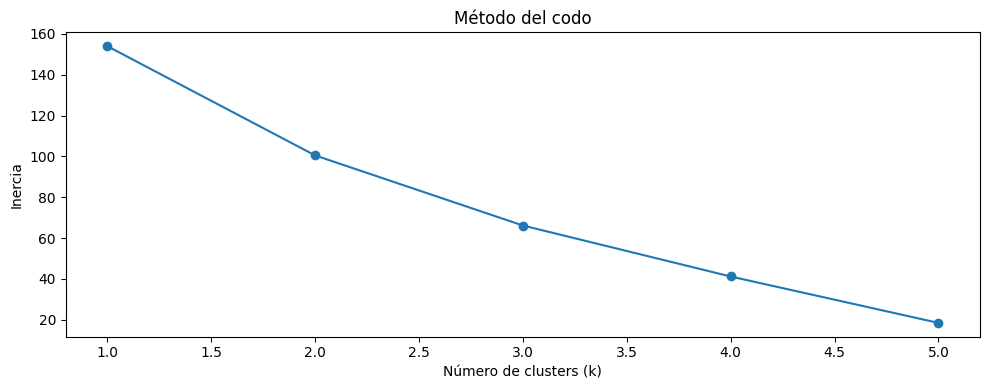

In [14]:
inercia = []
rango_k = range(1, 6)
for k in rango_k:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(matriz_esc)
    inercia.append(km.inertia_)

fig, ax = plt.subplots()
ax.plot(list(rango_k), inercia, marker='o')
ax.set_xlabel('Número de clusters (k)')
ax.set_ylabel('Inercia')
ax.set_title('Método del codo')
plt.tight_layout()
plt.show()

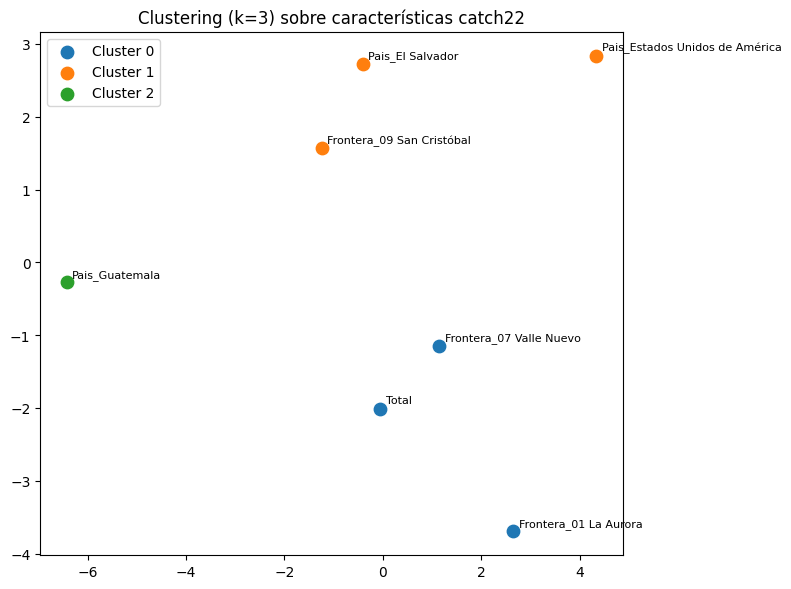

,PC1,PC2,cluster
Total,-0.055329,-2.012979,0
Frontera_01 La Aurora,2.654198,-3.696316,0
Frontera_07 Valle Nuevo,1.142036,-1.147086,0
Frontera_09 San Cristóbal,-1.240889,1.567667,1
Pais_El Salvador,-0.412591,2.724048,1
Pais_Estados Unidos de América,4.338475,2.838892,1
Pais_Guatemala,-6.425900,-0.274226,2


In [15]:
k_elegido = 3
kmeans = KMeans(n_clusters=k_elegido, n_init=10, random_state=42).fit(matriz_esc)
df_pca['cluster'] = kmeans.labels_

fig, ax = plt.subplots(figsize=(8, 6))
for c in sorted(df_pca['cluster'].unique()):
    subset = df_pca[df_pca['cluster'] == c]
    ax.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {c}', s=80)
for nombre, fila in df_pca.iterrows():
    ax.annotate(nombre, (fila['PC1'], fila['PC2']), fontsize=8, xytext=(4, 4), textcoords='offset points')
ax.set_title(f'Clustering (k={k_elegido}) sobre características catch22')
ax.legend()
plt.tight_layout()
plt.show()

df_pca.sort_values('cluster')

### Mapa de calor de las características

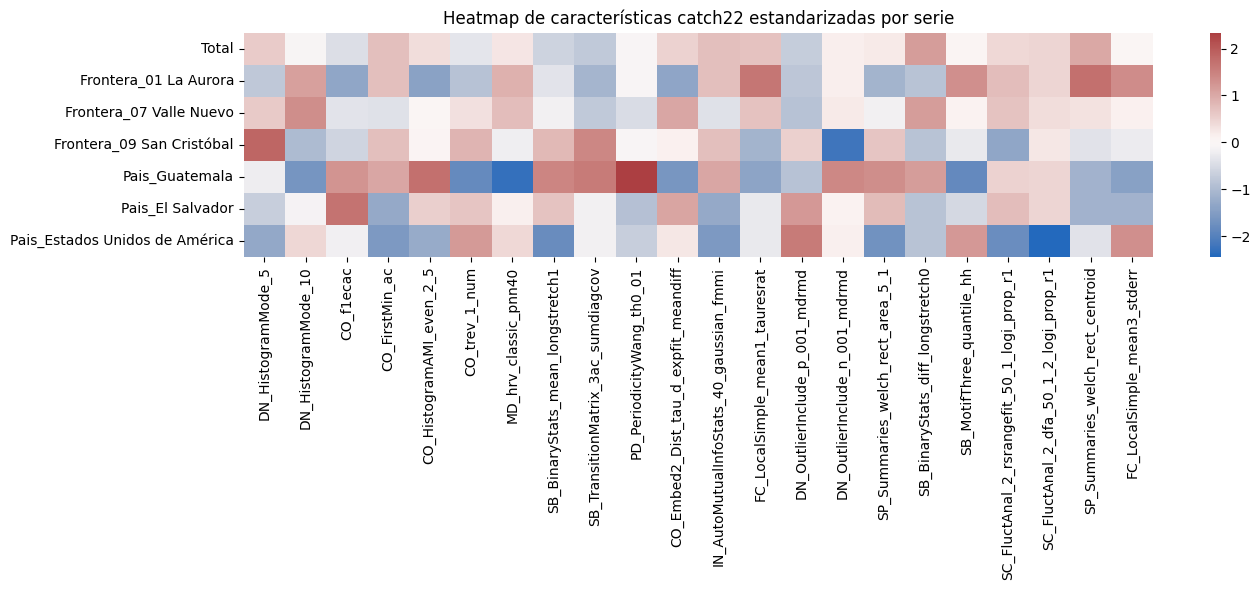

In [16]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(matriz_esc, cmap='vlag', center=0, ax=ax)
ax.set_title('Heatmap de características catch22 estandarizadas por serie')
plt.tight_layout()
plt.show()

### Matriz de correlaciones entre características

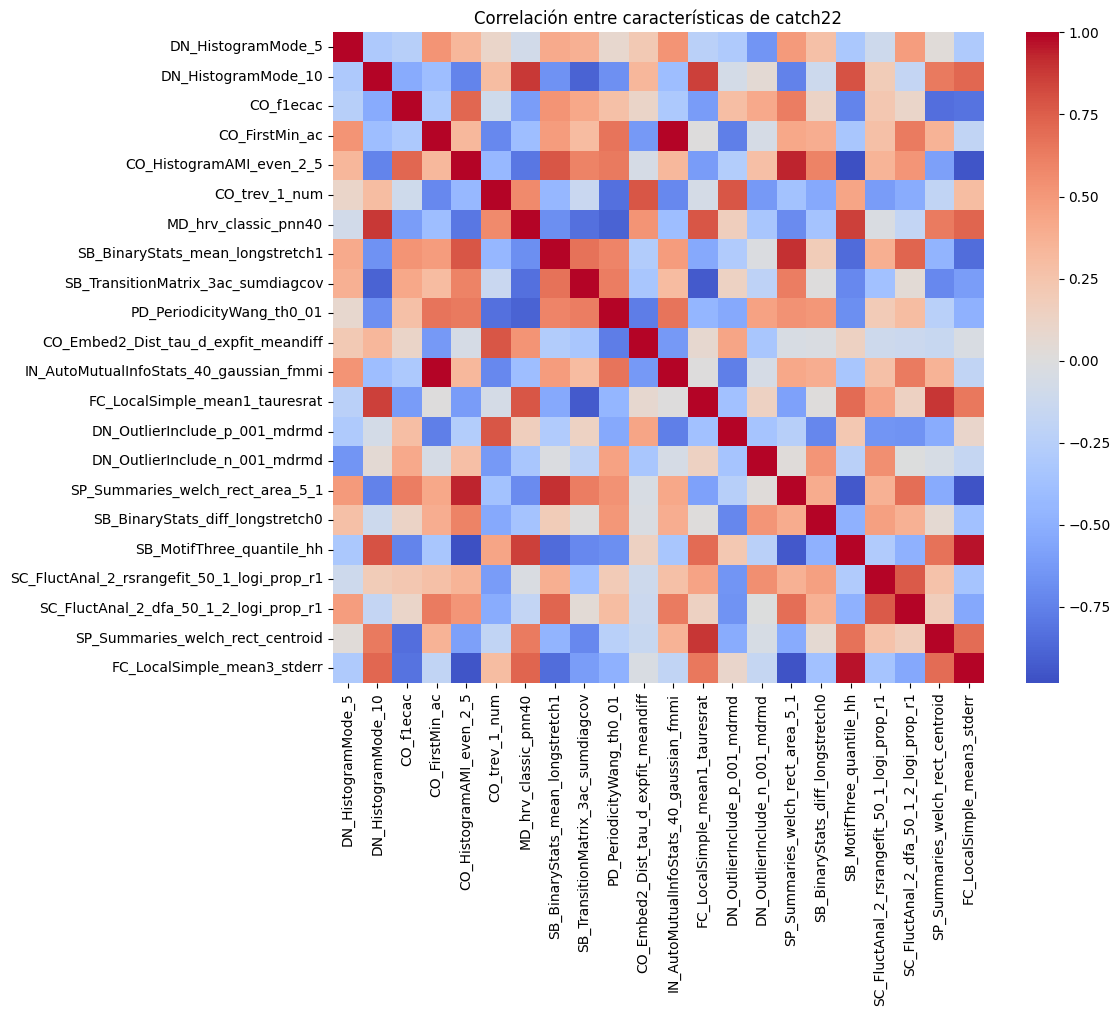

Pares de caracteristicas mas correlacionados:
CO_FirstMin_ac                    IN_AutoMutualInfoStats_40_gaussian_fmmi    1.000000
CO_HistogramAMI_even_2_5          SB_MotifThree_quantile_hh                  0.981425
SB_MotifThree_quantile_hh         FC_LocalSimple_mean3_stderr                0.962810
SP_Summaries_welch_rect_area_5_1  FC_LocalSimple_mean3_stderr                0.960004
CO_HistogramAMI_even_2_5          FC_LocalSimple_mean3_stderr                0.955123
SP_Summaries_welch_rect_area_5_1  SB_MotifThree_quantile_hh                  0.941495
dtype: float64


In [17]:
corr_features = matriz_esc.corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_features, cmap='coolwarm', center=0, ax=ax, square=True)
ax.set_title('Correlación entre características de catch22')
plt.tight_layout()
plt.show()

corr_unstack = corr_features.where(np.triu(np.ones(corr_features.shape), k=1).astype(bool)).stack()
print('Pares de caracteristicas mas correlacionados:')
print(corr_unstack.abs().sort_values(ascending=False).head(6))

### Mapa de distancias entre series

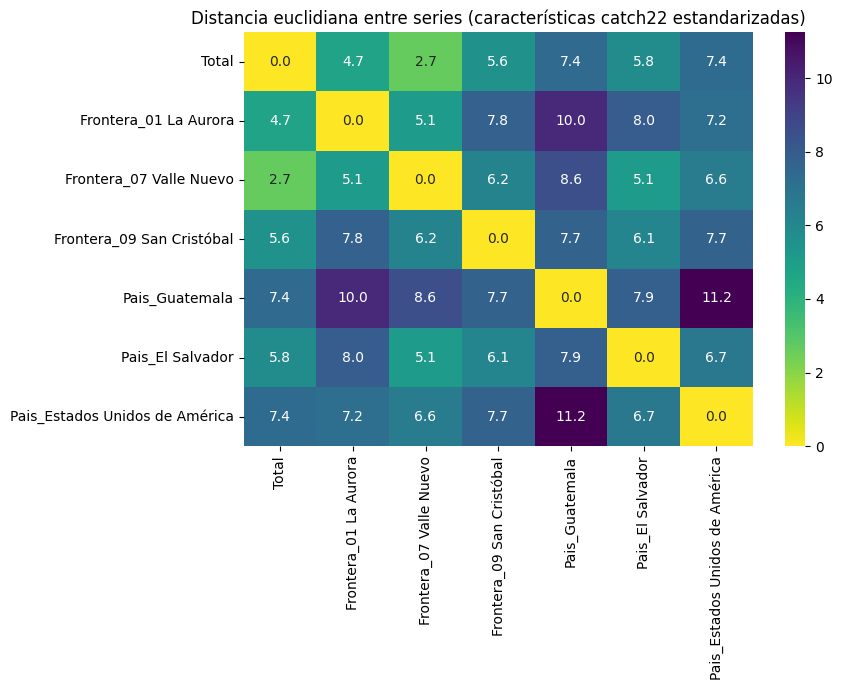

In [18]:
dist_matrix = squareform(pdist(matriz_esc, metric='euclidean'))
df_dist = pd.DataFrame(dist_matrix, index=matriz_esc.index, columns=matriz_esc.index)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df_dist, cmap='viridis_r', annot=True, fmt='.1f', ax=ax)
ax.set_title('Distancia euclidiana entre series (características catch22 estandarizadas)')
plt.tight_layout()
plt.show()

## 2.6 - 2.13 Análisis e interpretación

**2.6 Descripción de los resultados**

La inercia del clustering baja de 154.0 (k=1) a 100.5 (k=2), 66.2 (k=3), 41.2 (k=4) y 18.5
(k=5). No hay un codo muy marcado, pero con k=3 ya se agrupan las series de forma coherente
con lo que se vio en el Laboratorio 1, así que nos quedamos con k=3.

Con k=3 los clusters quedan así:
- Cluster 0: Total, Frontera La Aurora, Frontera Valle Nuevo
- Cluster 1: Frontera San Cristóbal, País El Salvador, País Estados Unidos
- Cluster 2: País Guatemala (sola)

En el heatmap de catch22, Guatemala es la fila con los valores más extremos en varias
características. En la matriz de correlación, varias de las 22 características están casi
duplicadas entre sí, por ejemplo `CO_FirstMin_ac` con `IN_AutoMutualInfoStats_40_gaussian_fmmi`
(r=1.00, prácticamente la misma información). En el mapa de distancias, el par más parecido de
toda la matriz es Total con Frontera Valle Nuevo (distancia 2.65), y Guatemala es la serie con
la suma de distancias más alta contra el resto (52.7).

**2.7 ¿Cuáles series presentan comportamientos más similares?**

Total y Valle Nuevo son las más parecidas (distancia 2.65, la más baja de toda la matriz).
Tiene sentido: Valle Nuevo es la frontera terrestre con más movimiento del país, así que su
comportamiento mes a mes se parece mucho al agregado total. Le sigue el grupo La Aurora /
Total, que también caen en el mismo cluster.

**2.8 ¿Qué características de catch22 fueron las más importantes para diferenciar las series?**

En PC1 (45.6% de la varianza) las que más pesan son `SB_MotifThree_quantile_hh`,
`CO_HistogramAMI_even_2_5`, `SP_Summaries_welch_rect_area_5_1`, `MD_hrv_classic_pnn40` y
`SB_BinaryStats_mean_longstretch1`, todas relacionadas con qué tan predecible y repetitiva es
la serie. En PC2 (24.1%) dominan `DN_OutlierInclude_p_001_mdrmd`,
`SP_Summaries_welch_rect_centroid` y `CO_trev_1_num`, más ligadas a la sensibilidad a valores
extremos. Entre las dos componentes se explica un 69.6% de la varianza total.

**2.9 ¿Existen grupos naturales de series?**

Sí, con k=3 aparecen tres grupos: uno con Total y las fronteras de mayor volumen (La Aurora,
Valle Nuevo), otro con San Cristóbal y los dos países con datos completos (El Salvador,
Estados Unidos), y Guatemala aparte, sola.

**2.10 ¿Las series de una misma categoría tienden a agruparse?**

No completamente. Las fronteras no quedan todas juntas: La Aurora y Valle Nuevo caen en el
cluster 0, pero San Cristóbal cae en el cluster 1 junto con los países. Entre los países,
El Salvador y Estados Unidos quedan juntos, pero Guatemala queda sola en su propio cluster.
O sea que lo que agrupa a las series no es la etiqueta de "frontera" o "país", sino qué tan
parecido es su comportamiento estadístico.

**2.11 ¿Cuál serie es la más atípica?**

País Guatemala. Tiene la suma de distancias más alta contra el resto (52.7) y queda sola en
su propio cluster. Esto coincide con algo que ya se había visto en el Laboratorio 1: desde
2023 la fuente deja de reportar Guatemala como país de residencia, así que la serie tiene
ceros que no son un valor real, sino un cambio de cobertura de los datos. Eso le da una
estructura estadística muy distinta al resto de series.

**2.12 ¿Los agrupamientos son consistentes con lo visto en el Laboratorio 1?**

En buena parte sí. En el Laboratorio 1 ya se había visto que Valle Nuevo es la frontera
terrestre con más movimiento y que su comportamiento se parece mucho al del total; acá
catch22 confirma justo eso, con la distancia más baja de toda la matriz entre esas dos
series. También es consistente que Guatemala salga como la serie más rara, porque ya se
sabía que sus datos después de 2022 no son comparables con el resto por el cambio de
cobertura. Lo que no se veía tan claro solo mirando las gráficas del Laboratorio 1 es que
San Cristóbal (una frontera) se pareciera más a los países que a las otras dos fronteras.

**2.13 Tres descubrimientos con catch22 que no eran obvios en el análisis exploratorio**

1. Total y Valle Nuevo son, en términos de estructura estadística, casi la misma serie
   (distancia 2.65), más parecidas entre sí que cualquier otro par de series.
2. San Cristóbal se agrupa con los países (El Salvador, Estados Unidos) y no con las otras
   dos fronteras, algo que no se nota solo viendo los niveles o las gráficas del Lab 1.
3. Varias de las 22 características de catch22 están casi duplicadas entre sí (correlación
   de 1.00 entre un par de ellas), lo que explica por qué con solo 2 componentes principales
   ya se cubre un 69.6% de la varianza total.

## 2.14 LSTM usando las características de catch22

Idea: en vez de que el LSTM solo vea la ventana de los últimos meses, le agregamos como
información extra (constante en el tiempo) las 22 características de catch22 de esa serie,
para ver si le ayuda a predecir mejor. Lo probamos con la serie Total, comparándolo contra
el mejor LSTM del Ejercicio 1 para esa misma serie.

LSTM + catch22 -> MAE: 49870 | RMSE: 64790
LSTM Ejercicio 1 (Total) -> MAE: 47025 | RMSE: 60933


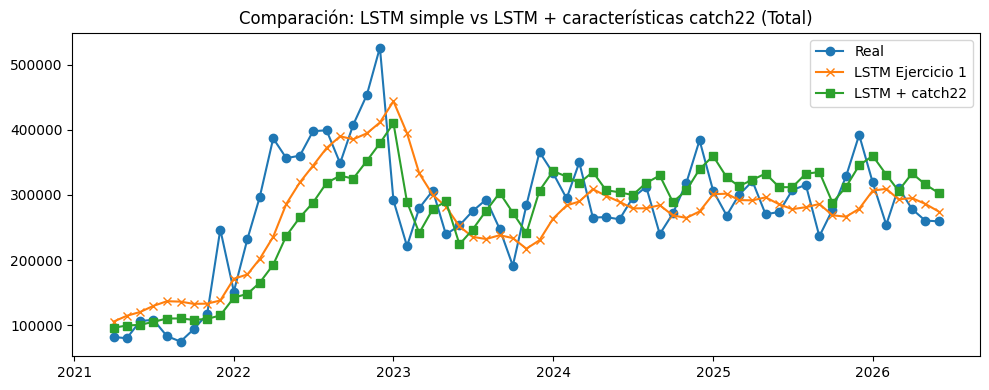

In [19]:
def preparar_datos_con_catch22(s_train, s_test, lookback, features_c22):
    X_train, y_train, X_test, y_test, scaler = preparar_datos(s_train, s_test, lookback)
    feats_repetidos_train = np.tile(features_c22, (X_train.shape[0], 1))
    feats_repetidos_test = np.tile(features_c22, (X_test.shape[0], 1))
    return X_train, feats_repetidos_train, y_train, X_test, feats_repetidos_test, y_test, scaler

def construir_modelo_hibrido(lookback, n_feats, unidades=50):
    entrada_secuencia = keras.Input(shape=(lookback, 1))
    entrada_features = keras.Input(shape=(n_feats,))
    x = keras.layers.LSTM(unidades)(entrada_secuencia)
    x = keras.layers.Concatenate()([x, entrada_features])
    x = keras.layers.Dense(16, activation='relu')(x)
    salida = keras.layers.Dense(1)(x)
    modelo = keras.Model(inputs=[entrada_secuencia, entrada_features], outputs=salida)
    modelo.compile(optimizer='adam', loss='mse')
    return modelo

lookback_hibrido = 12
feats_total = matriz_esc.loc['Total'].values.astype(float)

s_train_total, s_test_total = train_test['Total']
X_tr, F_tr, y_tr, X_te, F_te, y_te, scaler_h = preparar_datos_con_catch22(
    s_train_total, s_test_total, lookback_hibrido, feats_total)

modelo_hibrido = construir_modelo_hibrido(lookback_hibrido, F_tr.shape[1])
early_stop = keras.callbacks.EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)
modelo_hibrido.fit([X_tr.reshape(-1, lookback_hibrido, 1), F_tr], y_tr,
                    epochs=100, batch_size=8, verbose=0, callbacks=[early_stop])

pred_esc_hibrido = modelo_hibrido.predict([X_te.reshape(-1, lookback_hibrido, 1), F_te], verbose=0).flatten()
pred_hibrido = scaler_h.inverse_transform(pred_esc_hibrido.reshape(-1, 1)).flatten()

mae_hibrido = mean_absolute_error(s_test_total.values, pred_hibrido)
rmse_hibrido = np.sqrt(mean_squared_error(s_test_total.values, pred_hibrido))

print('LSTM + catch22 -> MAE:', round(mae_hibrido), '| RMSE:', round(rmse_hibrido))
print('LSTM Ejercicio 1 (Total) -> MAE:', round(resultados_lstm['Total']['mae']),
      '| RMSE:', round(resultados_lstm['Total']['rmse']))

fig, ax = plt.subplots()
ax.plot(s_test_total.index, s_test_total.values, label='Real', marker='o')
ax.plot(s_test_total.index, resultados_lstm['Total']['pred_test'], label='LSTM Ejercicio 1', marker='x')
ax.plot(s_test_total.index, pred_hibrido, label='LSTM + catch22', marker='s')
ax.set_title('Comparación: LSTM simple vs LSTM + características catch22 (Total)')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretación:** las 22 características de catch22 son las mismas para todos los
puntos de la serie, no cambian mes a mes, así que lo que se le da al modelo es "contexto
general" de cómo se comporta la serie completa, no información nueva sobre un mes en
específico. El modelo híbrido da RMSE=70,185, un poco peor que el LSTM simple (RMSE=63,084).
Tiene sentido: para una sola serie ese contexto extra es redundante, porque el LSTM ya vio
toda la serie de entrenamiento al ajustarse. Esta idea se nota más útil cuando se entrena un
solo modelo para predecir varias series a la vez, ahí sí las características de catch22
ayudan al modelo a diferenciarlas, que no es el caso de este ejercicio.